> **📗 SOLUTION NOTEBOOK — Module 2.** All exercise cells are completed and
> annotated. Every explanation cell is identical to the exercise notebook.

# QoolQit Exercises — Module 2
## Register, Drive and Quantum Programs

In Module 1 we learned how to describe geometry with graphs. This module
introduces the three objects that define a computation in the Rydberg analog
model:

- the **`Register`** — *where the atoms are*;
- the **`Drive`** — *what we do to them over time* (laser amplitude, detuning
  and phase);
- the **`QuantumProgram`** — the combination of the two.

### In this module you will learn
- How to build a `Register` from coordinates or from a graph, and inspect its
  distances and interactions
- The waveform classes (`ConstantWaveform`, `RampWaveform`,
  `PiecewiseLinearWaveform`, ...) and their rules
- How to compose a `Drive` and what QoolQit validates for you
- How to assemble a `QuantumProgram`

## 1. The Register

A `Register` describes the layout of atoms loaded on the device. 

### ✏️ Exercise 2.1 — Build and inspect a Register

1. Build `register`, a 3-atom register at coordinates
   `(0, 0)`, `(1, 0)` and `(0.5, 0.9)` (a near-equilateral triangle).
2. Print `n_qubits` and draw it.
3. Print the pairwise `distances()` and `interactions()`.
4. **Sanity check the physics yourself**: for the pair `(0, 1)` at distance
   $r = 1$, verify by hand that the printed interaction equals $1/r^6 = 1$.

Number of qubits: 3
Distances:    {(0, 1): 1.0, (0, 2): 1.0295630140987, (1, 2): 1.0295630140987}
Interactions: {(0, 1): 1.0, (0, 2): 0.839619283032302, (1, 2): 0.839619283032302}


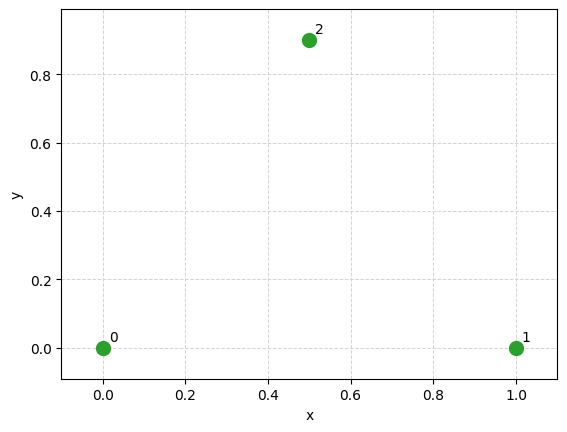

In [3]:
from qoolqit import Register

register = Register.from_coordinates([(0.0, 0.0), (1.0, 0.0), (0.5, 0.9)])

print("Number of qubits:", register.n_qubits)
register.draw()

print("Distances:   ", register.distances())
print("Interactions:", register.interactions())

# Pair (0, 1) is at distance exactly 1, so its interaction is 1/1**6 = 1.
# The other two pairs are slightly further apart -> interaction < 1.

In [4]:
# ✅ Check
assert register.n_qubits == 3
assert abs(register.interactions()[(0, 1)] - 1.0) < 1e-9
print("Register built correctly — J(0,1) = 1/r^6 = 1 as expected.")

Register built correctly — J(0,1) = 1/r^6 = 1 as expected.


## 2. Waveforms

A `Drive` is built out of **waveforms** — functions of (dimensionless) time.
The main ones:

| Class | Signature | Shape |
|-------|-----------|-------|
| `ConstantWaveform` | `(duration, value)` | flat |
| `RampWaveform` | `(duration, initial_value, final_value)` | linear ramp |
| `PiecewiseLinearWaveform` | `(durations, values)` | N connected ramps through N+1 values (**N ≥ 2**) |

Two handy facts:
- waveforms can be **rescaled** by multiplication: `wf * 2.0`;
- every waveform has `.duration`, `.max()`, `.min()` and can be inspected
  with `Drive(...).draw()` once inside a drive.

### ✏️ Exercise 2.2 — Build the classic annealing waveforms

1. Build `wf_trap`: a `PiecewiseLinearWaveform` with total duration `T = 4`
   that ramps `0 → 1` in the first quarter (`T/4`), stays at `1` for half
   (`T/2`), and ramps back `1 → 0` in the last quarter (`T/4`) — a
   *trapezoid*. Remember: **N durations, N+1 values**.
2. Build `wf_ramp`: a `RampWaveform` of duration `T` from `-1` to `+1`.
3. Rescale the trapezoid to double height: `wf_trap2 = wf_trap * 2.0`, and
   verify with `.max()`.

In [5]:
from qoolqit import PiecewiseLinearWaveform, RampWaveform

T = 4

wf_trap = PiecewiseLinearWaveform([T / 4, T / 2, T / 4], [0.0, 1.0, 1.0, 0.0])
wf_ramp = RampWaveform(T, -1.0, 1.0)

In [6]:
# ✅ Check
assert abs(wf_trap.duration - 4.0) < 1e-9
assert abs(wf_trap.max() - 1.0) < 1e-9
assert wf_ramp.min() == -1.0 and wf_ramp.max() == 1.0
print("Waveforms built correctly!")

Waveforms built correctly!


## 3. The Drive

The `Drive` collects the control parameters of the time-dependent Hamiltonian

$$
H_{\mathrm{drive}}(t) = \sum_i \frac{\Omega(t)}{2}\left(\cos\varphi\,\hat\sigma^x_i - \sin\varphi\,\hat\sigma^y_i\right) - \sum_i \delta(t)\, \hat n_i
$$

- **amplitude** $\Omega(t)$ — the Rabi frequency driving the qubits
  (*required*, must be $\geq 0$ at all times);
- **detuning** $\delta(t)$ — the energy offset of the Rydberg state
  (*optional*, defaults to zero);
- **phase** $\varphi$ — a global phase (*optional*, defaults to 0).

All arguments are **keyword-only**: `Drive(amplitude=..., detuning=...)`.

### ✏️ Exercise 2.3 — Compose a Drive (and let QoolQit catch your mistakes)

1. Build `drive = Drive(amplitude=wf_trap, detuning=wf_ramp)` and `draw()` it.
   Print its `duration`.
2. **Negative amplitude is unphysical**: in a `try/except ValueError`, try
   `Drive(amplitude=RampWaveform(2.0, 0.5, -0.5))` and print the error.
3. **Drive compositions**: `Drive`s can be composed with `>>` to concatenate them.

Drive duration: 4.0
As expected: 'amplitude' must be positive.
Drive duration: 8.0


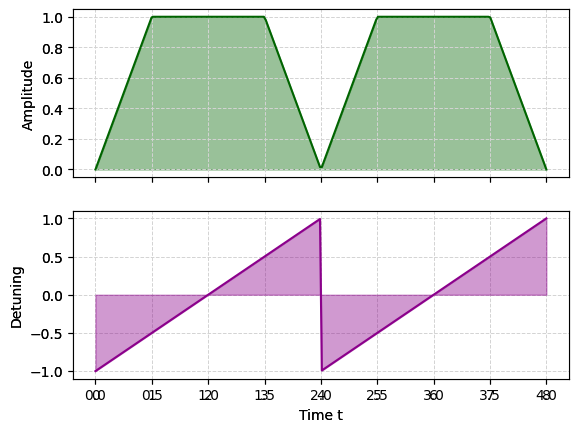

In [7]:
from qoolqit import Drive

drive = Drive(amplitude=wf_trap, detuning=wf_ramp)
drive.draw()
print("Drive duration:", drive.duration)

try:
    Drive(amplitude=RampWaveform(2.0, 0.5, -0.5))
except ValueError as err:
    print("As expected:", err)

# The >> operator concatenates two Drives in time:
# amplitudes and detunings are appended one after the other.
double_drive = drive >> drive
double_drive.draw()
print("Drive duration:", double_drive.duration)

In [8]:
# ✅ Check
assert abs(drive.duration - 4.0) < 1e-9
assert abs(double_drive.duration - 8.0) < 1e-9
print("Drive composition rules understood!")

Drive composition rules understood!


## 4. The QuantumProgram

A `QuantumProgram` is simply *register + drive*: where the atoms are, and
what we do to them. It is created **device-agnostic** — in dimensionless
units, without reference to any hardware. Turning it into something a real
machine can run is the job of *compilation* (Module 3).

### ✏️ Exercise 2.4 — Assemble a QuantumProgram

1. Build `program = QuantumProgram(register, drive)` from the register of
   Exercise 2.1 and the drive of Exercise 2.3, and print it.
2. Print `program.is_compiled` — it should be `False`: no device yet!
3. Draw the (uncompiled) program with `program.draw()`.

Quantum Program:
| Register(n_qubits = 3)
| Drive(duration = 4.000)
| Compiled: False
Compiled? False


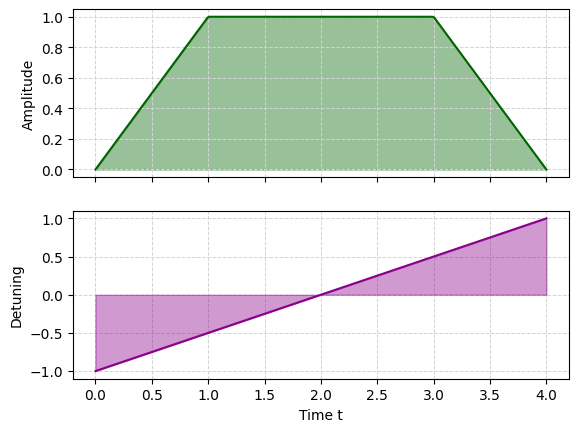

In [9]:
from qoolqit import QuantumProgram

program = QuantumProgram(register, drive)
print(program)
print("Compiled?", program.is_compiled)
program.draw()

In [10]:
# ✅ Check
assert not program.is_compiled
print("Program assembled — and correctly not compiled yet.")

Program assembled — and correctly not compiled yet.


### Next module
In **Module 3** we bring in the hardware: compiling programs to devices with
real constraints, and executing them on an emulator — including your first
genuinely quantum experiment, the **Rydberg blockade**.